# Source Exclusion Robustness Tests

**This notebook:** Task 1 — Baseline run with current pipeline.

## 1. Data Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from msa.utils.paths import get_gdelt_with_sentiment, get_joined_dataset

MAG7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA']

# Load FinBERT-scored articles
df = pd.read_parquet(get_gdelt_with_sentiment("parquet"))
df["seendate"] = pd.to_datetime(df["seendate"])

# Load joined dataset (articles + next-day OHLCV)
join = pd.read_parquet(get_joined_dataset("parquet"))
join["article_date"] = pd.to_datetime(join["article_date"])
join["price_date"] = pd.to_datetime(join["price_date"])

print(f"Articles: {len(df):,} rows {df['seendate'].min().date()} -> {df['seendate'].max().date()}")
print(f"Join table: {len(join):,} rows")
print(f"Unique domains: {df['domain'].nunique():,}")


Articles: 62,930 rows 2024-02-08 -> 2026-03-04
Join table: 62,885 rows
Unique domains: 5,126


In [5]:
# Domain volume distribution
domain_counts = df["domain"].value_counts()
domain_pct = domain_counts / len(df) * 100

top10 = pd.DataFrame({
    "articles": domain_counts.head(10),
    "pct": domain_pct.head(10).round(2)
})

print("Top 10 domains by article count:")
print(top10.to_string())
print(f"\nTop 5 share:  {domain_pct.head(5).sum():.1f}%")
print(f"Top 10 share: {domain_pct.head(10).sum():.1f}%")
print(f"Single-article domains: {(domain_counts == 1).sum():,} of {len(domain_counts):,}")


Top 10 domains by article count:
                              articles   pct
domain                                      
yahoo.com                         2539  4.03
fool.com                          2330  3.70
benzinga.com                      1800  2.86
indiatimes.com                    1314  2.09
marketscreener.com                1232  1.96
finance.yahoo.com                 1195  1.90
insidermonkey.com                  907  1.44
webpronews.com                     827  1.31
themarketsdaily.com                684  1.09
markets.financialcontent.com       643  1.02

Top 5 share:  14.6%
Top 10 share: 21.4%
Single-article domains: 1,898 of 5,126


In [6]:
# Sentiment bias by domain (top 20 by volume)
domain_sentiment = (
    df[df["domain"].isin(domain_counts.head(20).index)]
    .groupby("domain")["sentiment_score"]
    .agg(mean="mean", median="median", count="count", std="std")
    .sort_values("count", ascending=False)
    .round(3)
)
print("Sentiment profile — top 20 domains:")
print(domain_sentiment.to_string())


Sentiment profile — top 20 domains:
                               mean  median  count    std
domain                                                   
yahoo.com                    -0.042  -0.021   2539  0.114
fool.com                     -0.018  -0.008   2330  0.242
benzinga.com                 -0.082  -0.004   1800  0.344
indiatimes.com               -0.078   0.004   1314  0.349
marketscreener.com           -0.043  -0.003   1232  0.312
finance.yahoo.com             0.024   0.028   1195  0.461
insidermonkey.com            -0.002  -0.002    907  0.316
webpronews.com               -0.052   0.005    827  0.347
themarketsdaily.com          -0.054  -0.003    684  0.300
markets.financialcontent.com  0.097   0.087    643  0.595
tickerreport.com             -0.047   0.005    621  0.303
moneycontrol.com             -0.070   0.002    551  0.381
cnbc.com                     -0.064  -0.021    534  0.319
forbes.com                   -0.041  -0.006    528  0.289
dailypolitical.com           -0.050 

In [7]:
# Apply sentiment_present threshold
df["sentiment_present"] = df["sentiment_score"].abs() > 0.05
join["sentiment_present"] = join["sentiment_score"].abs() > 0.05
join["next_day_ret"] = (join["next_close"] - join["next_open"]) / join["next_open"]

mag7_df = df[df["ticker"].isin(MAG7)].copy()
mag7_join = join[join["ticker"].isin(MAG7)].copy()

print(f"MAG7 articles: {len(mag7_df):,}")
print(f"Sentiment present: {mag7_df['sentiment_present'].sum():,} ({mag7_df['sentiment_present'].mean():.1%})")
print(f"MAG7 join rows: {len(mag7_join):,}")

MAG7 articles: 62,930
Sentiment present: 29,636 (47.1%)
MAG7 join rows: 62,885


In [8]:
# Daily median sentiment per ticker (baseline)
daily_sentiment = (
    mag7_join[mag7_join["sentiment_present"]]
    .groupby(["article_date", "ticker"])["sentiment_score"]
    .median()
    .reset_index()
    .rename(columns={"sentiment_score": "median_sentiment"})
)

# Daily ticker coverage
daily_coverage = daily_sentiment.groupby("article_date")["ticker"].nunique()

print("Daily sentiment coverage (baseline):")
print(f"  Total days with any sentiment: {len(daily_coverage):,}")
print(f"  Days with 5+ MAG7 tickers:    {(daily_coverage >= 5).sum():,}")
print(f"  Days with 7/7 MAG7 tickers:   {(daily_coverage == 7).sum():,}")
print(f"  Mean tickers/day:              {daily_coverage.mean():.2f}")


Daily sentiment coverage (baseline):
  Total days with any sentiment: 469
  Days with 5+ MAG7 tickers:    82
  Days with 7/7 MAG7 tickers:   81
  Mean tickers/day:              2.48


C:\Users\mathe\AppData\Local\Temp\ipykernel_51056\1231118579.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


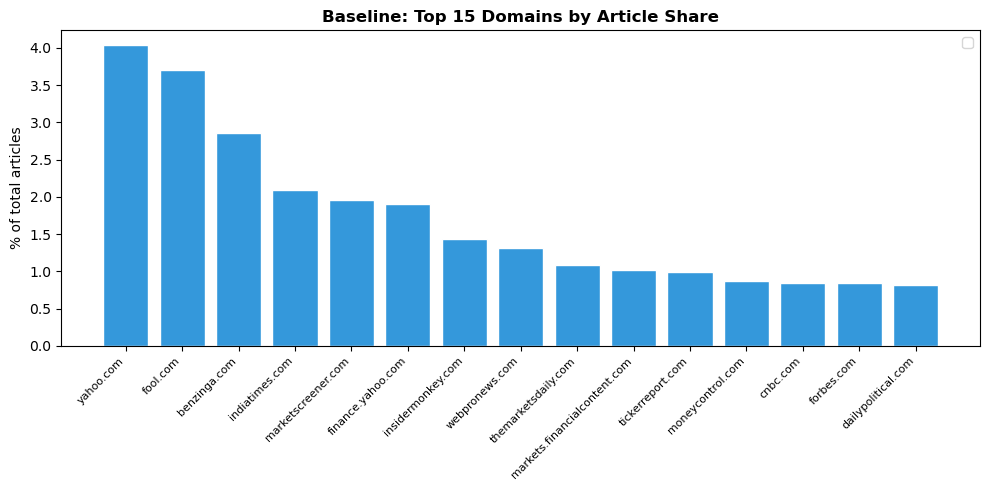

In [18]:
# Domain share bar chart
fig, ax = plt.subplots(figsize=(10, 5))
top15 = domain_pct.head(15)
ax.bar(range(len(top15)), top15.values, color="#3498db", edgecolor="white")
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of total articles")
ax.set_title("Baseline: Top 15 Domains by Article Share", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

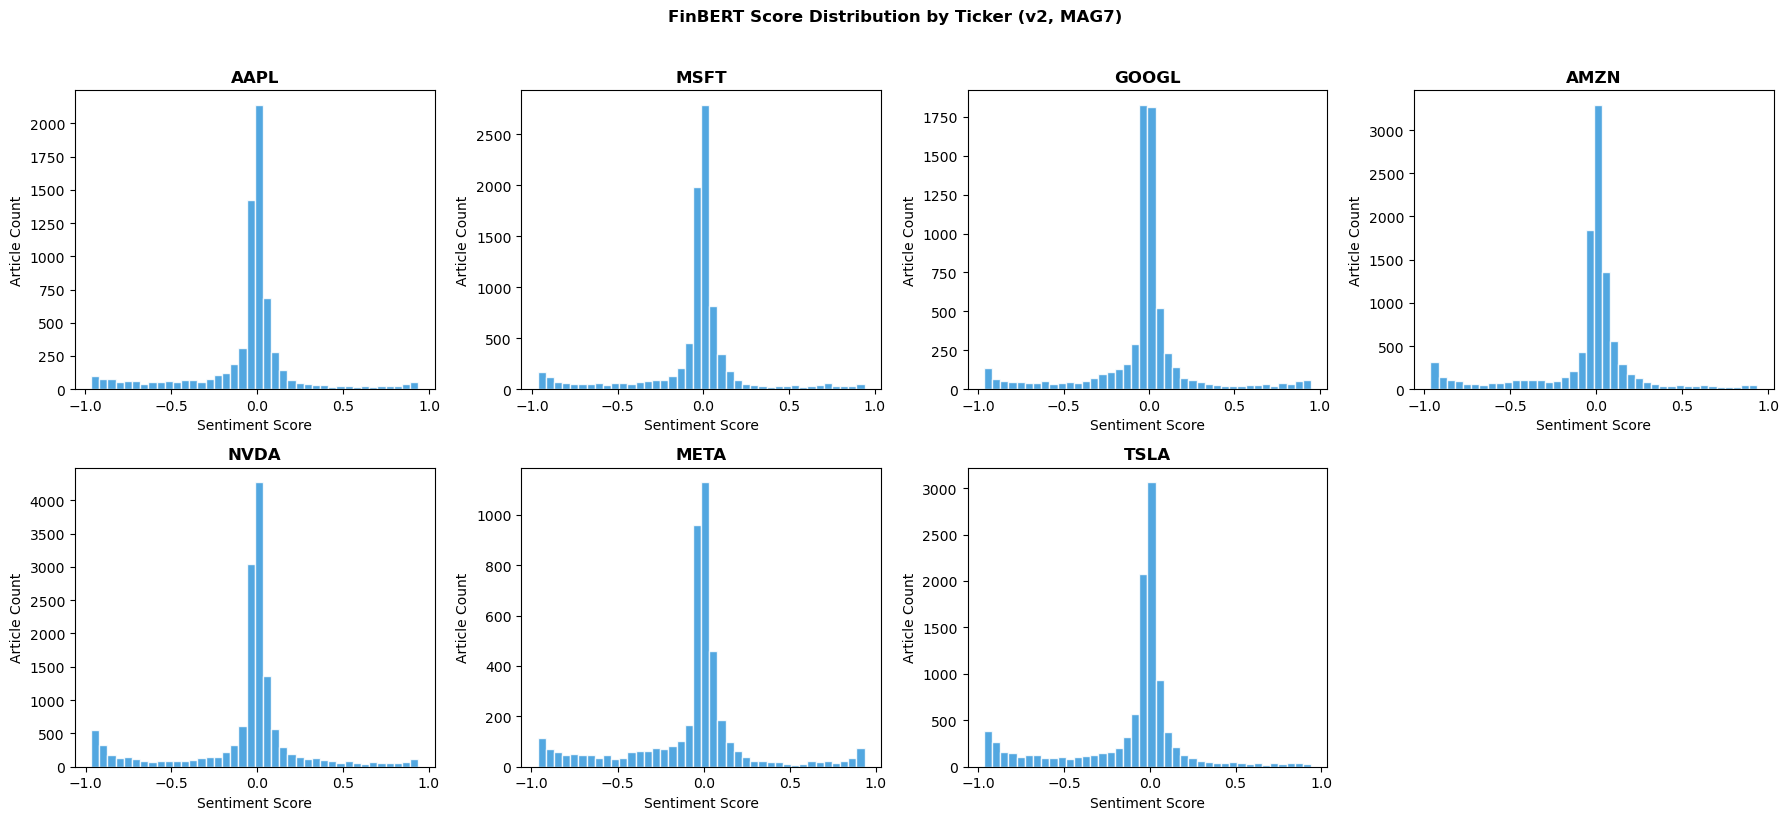

In [19]:
v2_mag7 = df[df["ticker"].isin(MAG7)].copy()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, ticker in enumerate(MAG7):
    ax = axes[i]
    scores = v2_mag7[v2_mag7["ticker"] == ticker]["sentiment_score"]
    ax.hist(scores, bins=40, color="#3498db", edgecolor="white", alpha=0.85)
    ax.set_title(ticker, fontweight="bold")
    ax.set_xlabel("Sentiment Score")
    ax.set_ylabel("Article Count")

axes[-1].set_visible(False)  # hides empty 8th slot

plt.suptitle("FinBERT Score Distribution by Ticker (v2, MAG7)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()